# Jasmin Experiments

Notebook orchestration only. Shared implementation lives in `src/`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.common.config import load_config
from src.common.data import SpacepressoDataModule
from src.common.paths import resolve_path
from src.common.seed import set_seed
from src.common.submission import SubmissionWriter, validate_submission
from src.common.training import ExperimentRunner
from src.common.visualization import show_predictions
from src.methods import get_method_class


In [2]:
config = load_config(ROOT / "configs/patchcore_lite/jasmin_test.yaml")
set_seed(config.get("seed", 42))

local_data = ROOT / "data" / "spacepresso"
if local_data.exists():
    config["data"]["root"] = str(local_data)
config["data"]["load_images"] = False

dm = SpacepressoDataModule(**config["data"])
train_good = dm.load_train_good()
train_anomalies = dm.load_train_anomalies()
test = dm.load_test()
print({"train_good": len(train_good), "train_anomalies": len(train_anomalies), "test": len(test)})

{'train_good': 19005, 'train_anomalies': 235, 'test': 5910}


c:\Users\PC\anaconda3\envs\adl_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\PC\anaconda3\envs\adl_project\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PC\.cache\huggingface\hub\models--timm--wide_resnet50_2.racm_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to a

Using PatchCore backbone: wide_resnet50_2
Fitting PatchCore memory bank for class_01: 2600 images


PatchCore feature extraction: 100%|██████████| 650/650 [01:03<00:00, 10.26it/s]


Seen bank: 2,038,400 patches x 1536 dims; candidate pool: 6,000 patches; coreset: 2,000 patches
Fitting PatchCore memory bank for class_02: 2135 images


PatchCore feature extraction: 100%|██████████| 534/534 [00:47<00:00, 11.31it/s]


...

PatchCore feature extraction: 100%|██████████| 537/537 [00:41<00:00, 12.99it/s]


Seen bank: 1,681,680 patches x 1536 dims; candidate pool: 6,000 patches; coreset: 2,000 patches
Fitting PatchCore memory bank for class_08: 2045 images


PatchCore feature extraction: 100%|██████████| 512/512 [00:39<00:00, 13.01it/s]


Seen bank: 1,603,280 patches x 1536 dims; candidate pool: 6,000 patches; coreset: 2,000 patches


PatchCore inference: 100%|██████████| 240/240 [00:32<00:00,  7.45it/s]


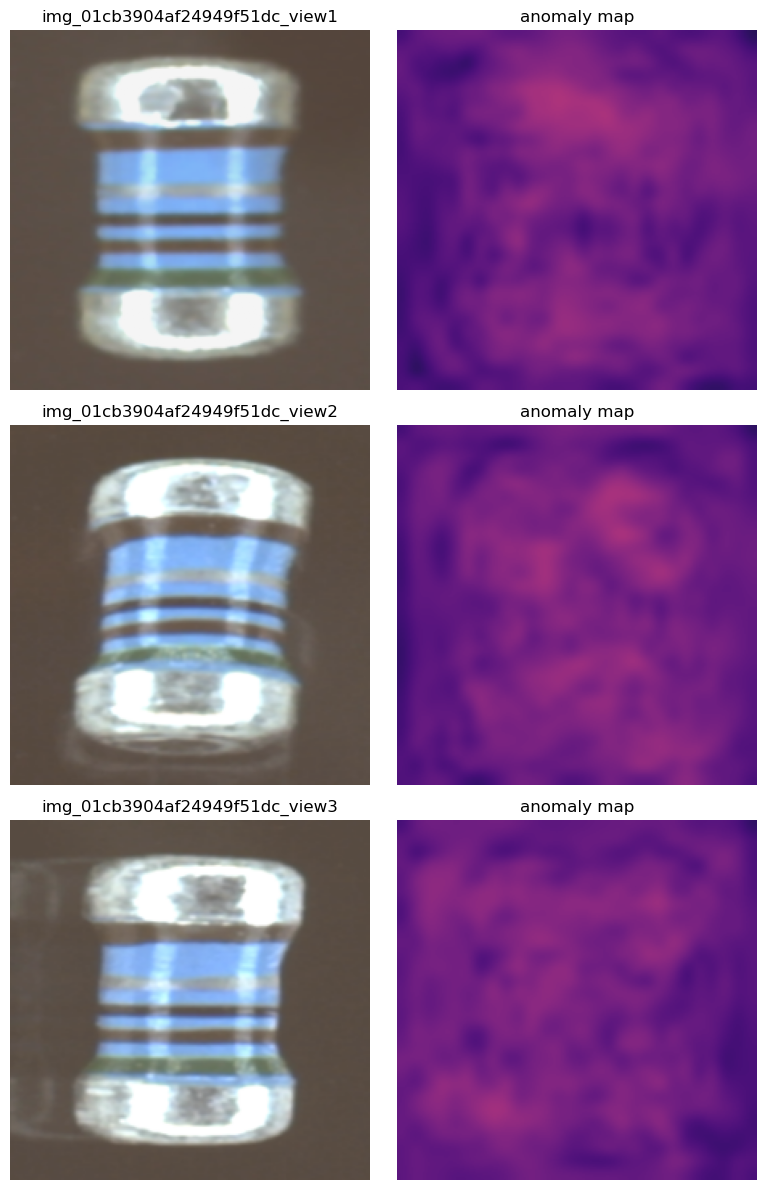

In [3]:
if train_good and test:
    Method = get_method_class(config["method"]["name"])
    runner = ExperimentRunner(Method(config), config)
    runner.fit(train_good)
    predictions = runner.predict(test)
    show_predictions(test, predictions, n=3)
else:
    predictions = {}
    print("Dataset is empty or not found. Update config['data']['root'] before running.")


In [ ]:
if predictions:
    import zipfile, random
    from src.common.submission import _prepare_prediction_map
    from src.common.q8rle import float_matrix_to_q8rle, q8rle_to_float_matrix

    expected_shape = (config["data"]["image_size"], config["data"]["image_size"])
    sorted_ids = sorted(predictions)
    assert len(sorted_ids) == len(test), f"Expected {len(test)} predictions, got {len(sorted_ids)}"

    sample_indices = set(random.sample(range(len(sorted_ids)), min(5, len(sorted_ids))))
    sampled_labels = {}

    zip_path = resolve_path(config["submission"]["output_path"], ROOT).with_suffix(".zip")
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    # Stream CSV directly into zip — never holds 800MB in RAM
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        with zf.open(zip_path.stem + ".csv", "w") as f:
            f.write(b"ID,Label\n")
            for i, img_id in enumerate(sorted_ids):
                label = float_matrix_to_q8rle(_prepare_prediction_map(predictions[img_id]))
                f.write(f"{img_id},{label}\n".encode("utf-8"))
                if i in sample_indices:
                    sampled_labels[img_id] = label

    # Spot-check sampled rows
    for img_id, label in sampled_labels.items():
        assert label.startswith("q8rle"), f"Bad label for {img_id}"
        assert q8rle_to_float_matrix(label).shape == expected_shape, f"Shape mismatch for {img_id}"

    print(f"Validated: {len(sorted_ids)} rows, spot-checked {len(sampled_labels)}, shape {expected_shape}")
    print(f"Saved: {zip_path} ({zip_path.stat().st_size / 1024**2:.1f} MB)")

In [ ]:
import zipfile

csv_path = resolve_path(config["submission"]["output_path"], ROOT)
zip_path = csv_path.with_suffix(".zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
    zf.write(csv_path, csv_path.name)
print(f"Submission zip: {zip_path} ({zip_path.stat().st_size / 1024**2:.1f} MB)")